In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st
import statsmodels.formula.api as smf
import statsmodels.stats as sms
import statsmodels.api as sm

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import seaborn as sns
import altair as alt

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
kc = pd.read_csv('kc_house_data.csv')

In [3]:
kc.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [4]:
kc['date'] = pd.to_datetime(kc.date)

In [5]:
sqft_to_sqmeters = 0.09290303997

In [6]:
kc = kc.astype({'sqft_living': float, 'sqft_lot': float, 
                'sqft_above': float, 'sqft_basement': float,
                'sqft_living15': float, 'sqft_lot15': float})

In [7]:
kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] =\
kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] * sqft_to_sqmeters

In [8]:
kc.columns = ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqm_living',
       'sqm_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqm_above', 'sqm_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqm_living15', 'sqm_lot15']

In [9]:
kc = kc.loc[:, ['id', 'date', 'price', 
            'floors', 'bedrooms', 'bathrooms', 
            'yr_built', 'yr_renovated',
            'waterfront', 'view', 'condition', 'grade', 
            'sqm_living', 'sqm_lot', 
            'sqm_above', 'sqm_basement',
            'sqm_living15', 'sqm_lot15',
            'lat', 'long']]

In [10]:
kc.loc[kc.yr_renovated == 0, 'yr_renovated'] = np.nan

In [11]:
kc.loc[kc.sqm_basement == 0, 'sqm_basement'] = np.nan

In [12]:
alt.data_transformers.disable_max_rows()
alt.renderers.enable('png')

RendererRegistry.enable('png')

In [13]:
base = pio.templates["simple_white"]
custom_template = base.layout.template

custom_template.layout.update(
    margin=dict(l=50, r=0, t=20, b=50),
    xaxis=dict(
        title_standoff=0,
        ticks="outside",
        showgrid=True,
        gridcolor='#bbb'
    ),
    yaxis=dict(
        title_standoff=0,
        ticks="outside",
        showgrid=True,
        gridcolor='#bbb'
    ),
    colorscale=dict(
        sequential=px.colors.sequential.Inferno
    ),
    colorway=px.colors.qualitative.T10
)

pio.templates["tight"] = custom_template
pio.templates.default = "tight"

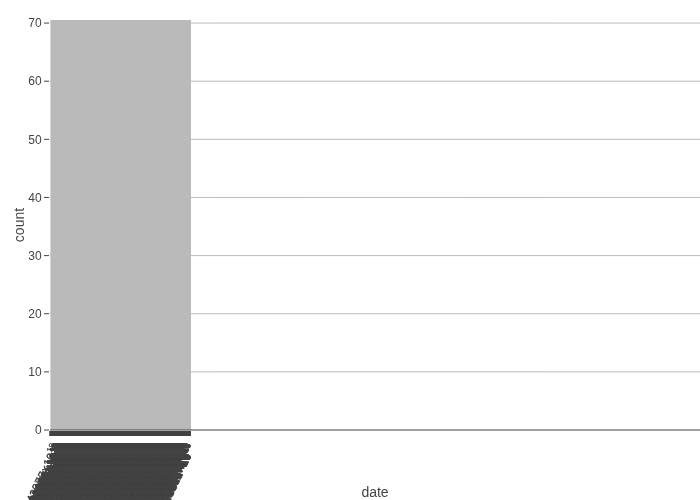

In [14]:
px.histogram(kc, 'date', height=400
).update_traces(xbins_start=kc.date.min(),
                xbins_end=kc.date.max(),
                xbins_size='D',
                marker_cornerradius=20
).update_xaxes(dtick=7*24*60*60*1000,
               minor_dtick=24*60*60*1000,
               minor_showgrid=True,
               tickangle=-65,
               ticks='outside',
               tick0='2014-05-05'
).update_layout(margin=dict(b=70)).show(renderer='png')

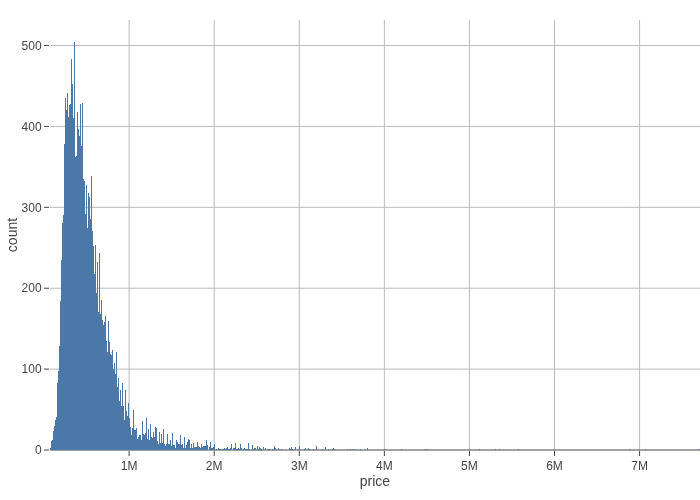

In [15]:
px.histogram(kc, x='price', height=200
).update_traces(
    xbins_size=10**4,
    marker_cornerradius=10
).show(renderer='png')

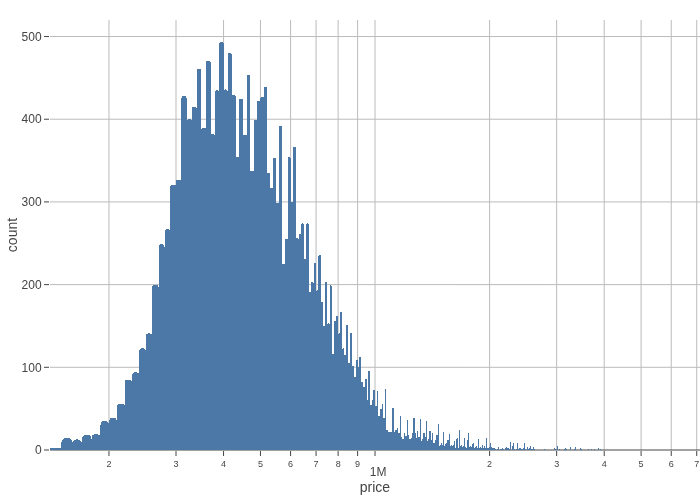

In [16]:
px.histogram(kc, x='price', height=200, log_x=True
).update_traces(
    xbins_size=10**4,
    marker_cornerradius=10
).show(renderer='png')

In [17]:
pd.DataFrame(kc.floors.value_counts()).T

floors,1.0,2.0,1.5,3.0,2.5,3.5
count,10680,8241,1910,613,161,8


In [18]:
pd.DataFrame(kc.bedrooms.value_counts()).T

bedrooms,3,4,2,5,6,1,7,0,8,9,10,11,33
count,9824,6882,2760,1601,272,199,38,13,13,6,3,1,1


In [19]:
pd.DataFrame(kc.bathrooms.value_counts()).T.iloc[:,:15]

bathrooms,2.50,1.00,1.75,2.25,2.00,1.50,2.75,3.00,3.50,3.25,3.75,4.00,4.50,4.25,0.75
count,5380,3852,3048,2047,1930,1446,1185,753,731,589,155,136,100,79,72


In [20]:
pd.DataFrame(kc.bathrooms.value_counts()).T.iloc[:,15:]

bathrooms,4.75,5.00,5.25,0.00,5.50,1.25,6.00,0.50,5.75,6.75,8.00,6.50,6.25,7.75,7.50
count,23,21,13,10,10,9,6,4,4,2,2,2,2,1,1


In [21]:
kc[['waterfront', 'view', 'condition', 'grade']].apply(lambda x: x.value_counts()).T.fillna('')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
waterfront,21450.0,163.0,,,,,,,,,,,,
view,19489.0,332.0,963.0,510.0,319.0,,,,,,,,,
condition,,30.0,172.0,14031.0,5679.0,1701.0,,,,,,,,
grade,,1.0,,3.0,29.0,242.0,2038.0,8981.0,6068.0,2615.0,1134.0,399.0,90.0,13.0


Text(0.5, 0, 'square meters')

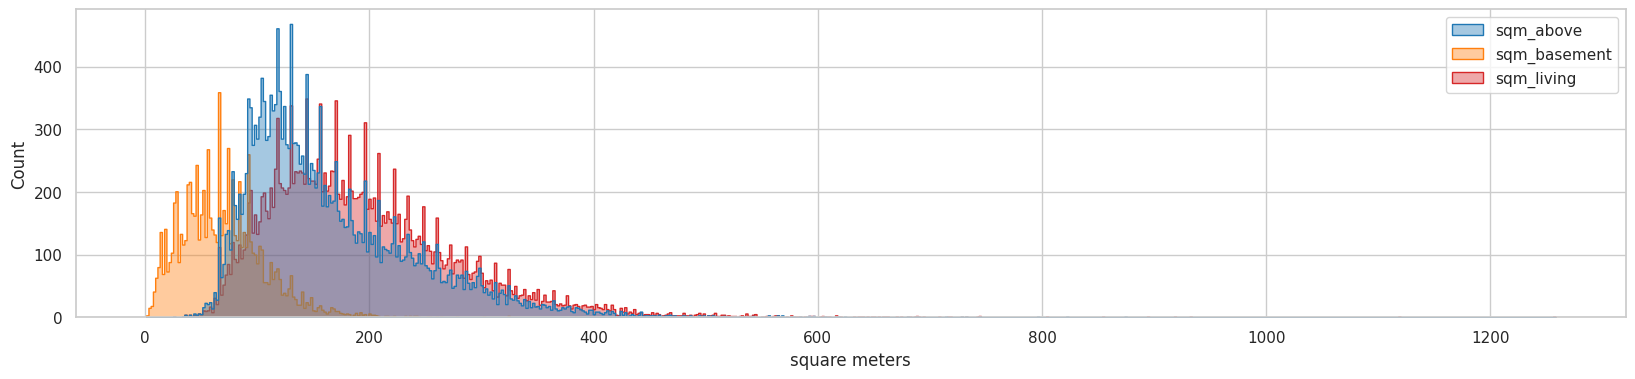

In [22]:
sns.set(rc={"figure.figsize":(20,4)})
sns.set_style('whitegrid')
sns.histplot(kc[['sqm_above', 'sqm_basement', 'sqm_living']],
             binwidth=2, palette=['#1f77b4', '#ff7f0e', '#d62728'],
             multiple='layer', element='step', alpha=0.4, linewidth=1)
plt.xlabel('square meters')

Text(0.5, 0, 'square meters')

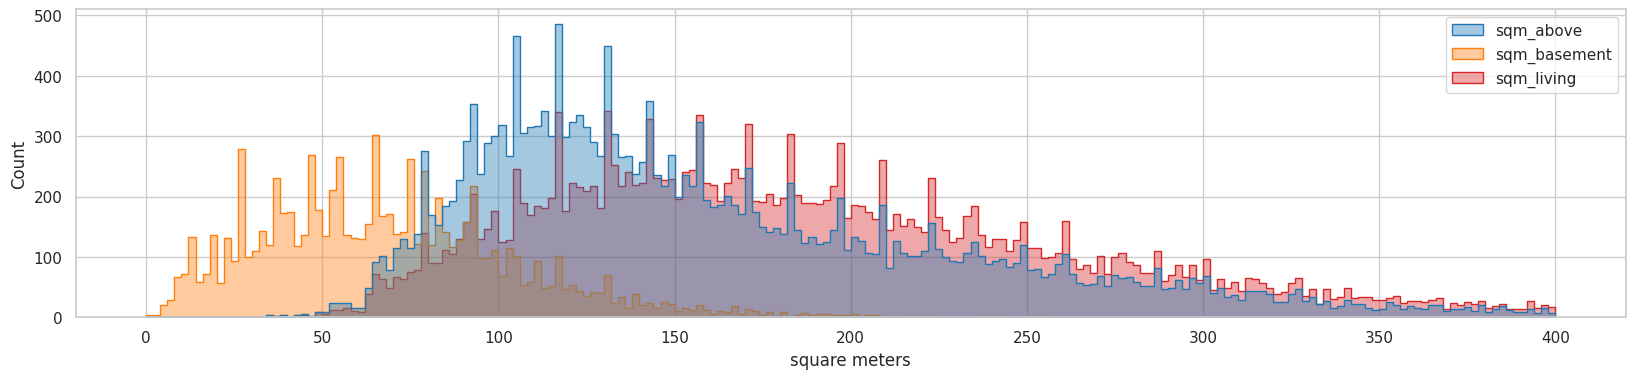

In [23]:
sns.set(rc={"figure.figsize":(20,4)})
sns.set_style('whitegrid')
sns.histplot(kc[['sqm_above', 'sqm_basement', 'sqm_living']],
             palette=['#1f77b4', '#ff7f0e', '#d62728'],
             binrange=(0,400), binwidth=2, multiple='layer', element='step', 
             alpha=0.4, linewidth=1)
plt.xlabel('square meters')

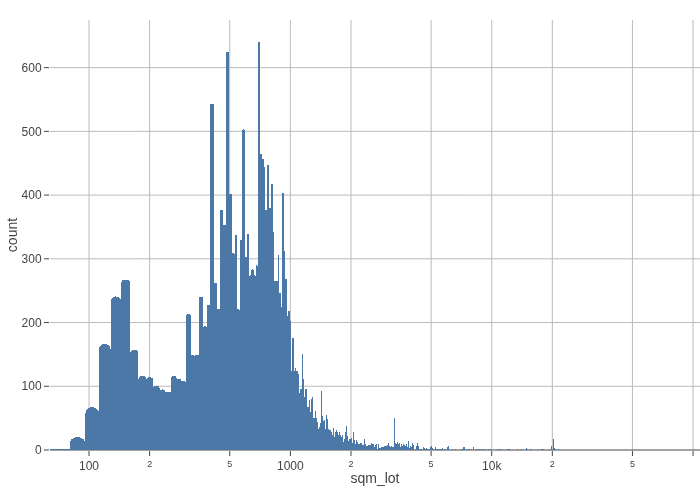

In [24]:
px.histogram(kc, x='sqm_lot', height=200, log_x=True
).update_traces(xbins_size=16, marker_cornerradius=10).show(renderer='png')

In [25]:
kc.id.count()

np.int64(21613)

In [26]:
kc.loc[kc.sqm_living==kc.sqm_above,'sqm_above'].count()

np.int64(13126)

In [27]:
kc.loc[kc.sqm_above==kc.sqm_basement,'sqm_basement'].count()

np.int64(551)

In [28]:
kc.sqm_basement.isna().sum()

np.int64(13126)

In [29]:
(kc.sqm_basement.isna() == np.where(kc.sqm_living==kc.sqm_above, 1, 0)).sum()

np.int64(21613)

Text(0.5, 0, 'year built')

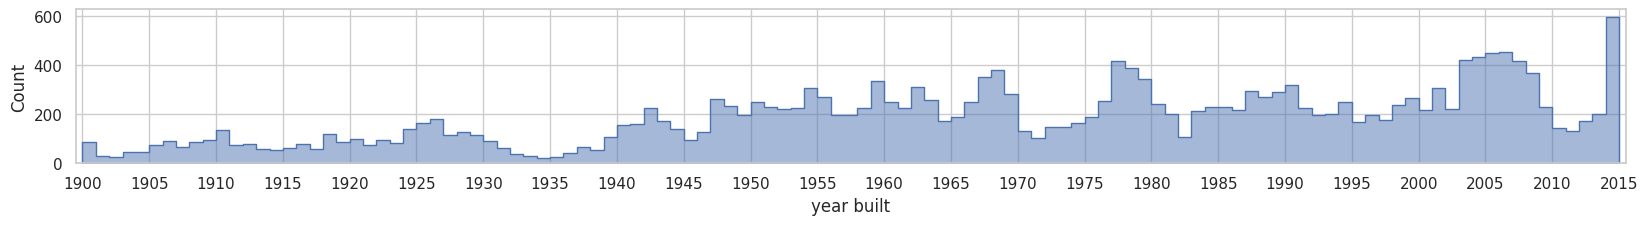

In [30]:
sns.set(rc={"figure.figsize":(20,2)})
sns.set_style('whitegrid')
sns.histplot(data=kc.yr_built, binrange=(1900,2015), binwidth=1, element='step', alpha=0.5)
plt.locator_params(axis='x', nbins=40)
plt.xlim(1899.5,2015.5)
plt.xlabel('year built')

Text(0.5, 0, 'year of renovation')

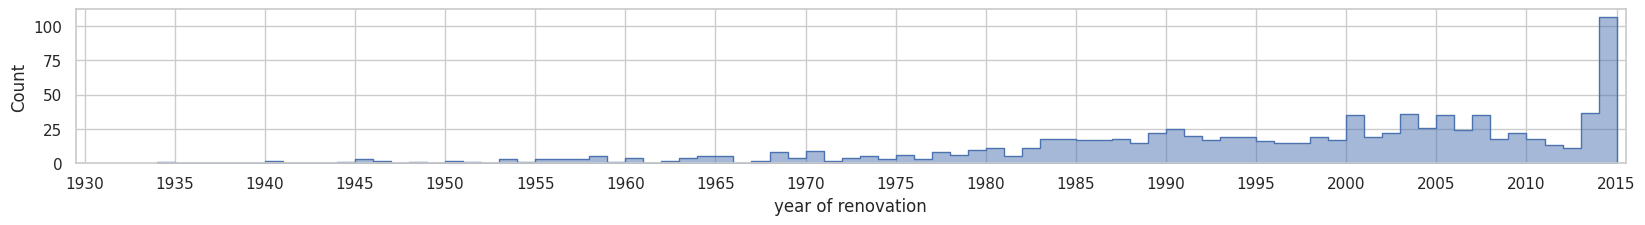

In [31]:
sns.set(rc={"figure.figsize":(20,2)})
sns.set_style('whitegrid')
sns.histplot(data=kc.yr_renovated, binrange=(1934,2015), binwidth=1, element='step', alpha=0.5)
plt.locator_params(axis='x', nbins=30)
plt.xlim(1929.5,2015.5)
plt.xlabel('year of renovation')

In [32]:
# px.scatter_map(kc, lat='lat', lon='long', size='sqm_living', size_max=10, zoom=9, template='plotly_dark',
#                color='price', map_style='carto-darkmatter', color_continuous_scale='plasma'
#                ).update_layout(margin=dict(l=0,r=0,b=0,t=0)
#                ).show(renderer='png', width=1500, height=500)

##### Regressions

In [33]:
# alt.Chart(kc).mark_circle(
#     size=20, opacity=0.75, tooltip=True
# ).encode(
#     alt.X(alt.repeat("column"), type='quantitative').scale(zero=False).axis(format='~s'),
#     alt.Y(alt.repeat("row"), type='quantitative').scale(zero=False).axis(format='~s'),
#     alt.Color('condition:N').scale(scheme='tableau10')
# ).properties(
#     width=200,
#     height=200
# ).repeat(
#     row=['price', 'grade', 'sqm_living', 'sqm_lot', 'yr_built', 'yr_renovated'],
#     column=['price', 'grade', 'sqm_living', 'sqm_lot', 'yr_built', 'yr_renovated']
# ).configure_facet(spacing=0
# ).configure_legend(symbolOpacity=1)

In [34]:
###### Regression assumptions:
######
###### 1) Linearity - residual plot (against predicted values Y^)
######    - change reg. model, transform predictors
###### 2) Homoscedasticity -> risk of small p-values (type I error) - residual plot
######    - use Poisson regression (if counts) or weighted least squares regression
######    - transform the data
######    - use robust standard errors (of coefficients) - it transforms p-values
###### 3) Normality - kdeplot/histogram or QQplot, for residuals, Jarque-Bera
######    - add expl. variable
######    - transform data / change model
######    - remove outliers - Cook's distance ( threshold = 4 / (n - k - 1) )
###### 4) Independence (no autocorelation)
######    = if timeseries, check residuals vs time variable - transform the data
######    = Durbin-Watson (must be between 2 and 3)
###### 5) No colinearity - large condition number, Variance inflation factor (VIF) >5 
######                   -> inflated p-values, wide confidence intervals
######    - remove or combine variables (ex height and weight into bmi)
######    - principal component regression
######    - partial least squares regression

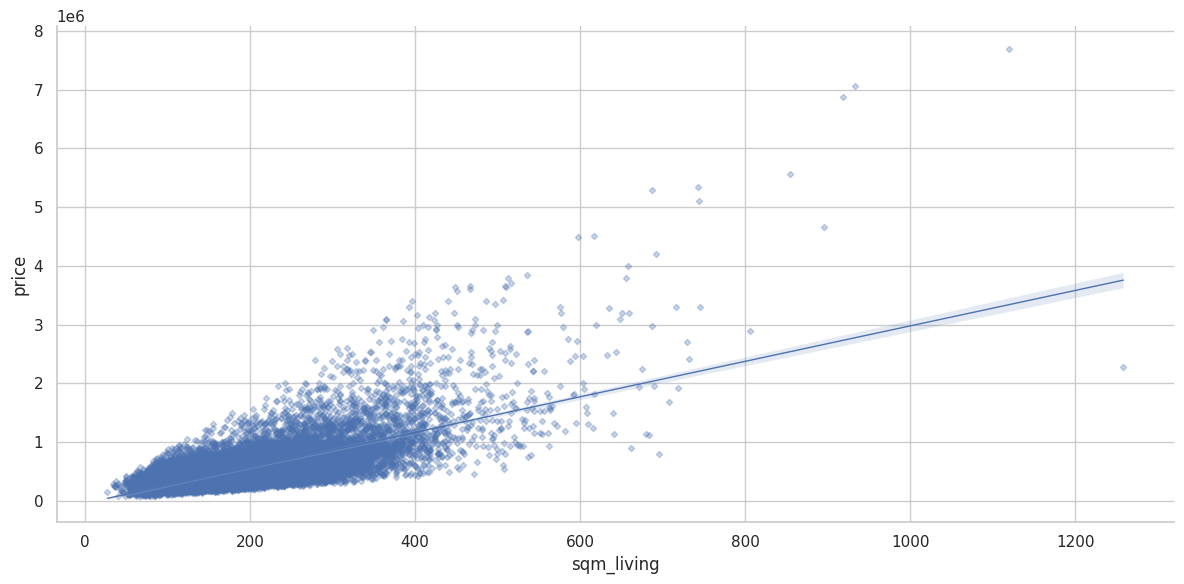

In [35]:
sns.set_style('whitegrid')
sns.lmplot(kc, x='sqm_living', y='price', # hue='waterfront',
           aspect=2, height=6, markers='D',
           scatter_kws={'s': 10, 'alpha':0.3}, line_kws={'linewidth':1})

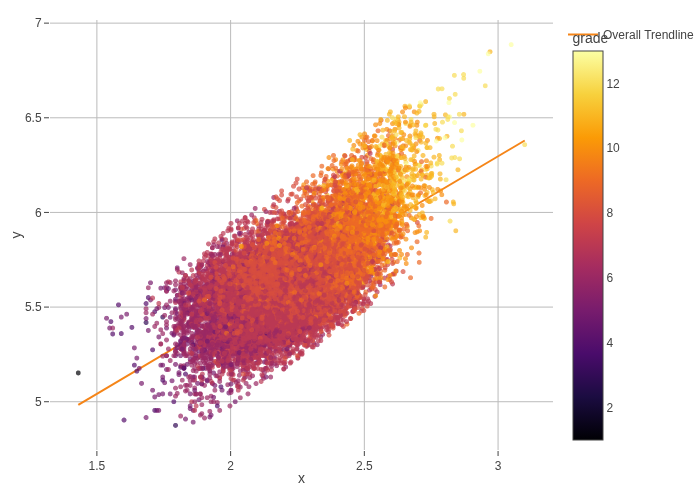

In [36]:
px.scatter(kc, x=np.log10(kc.sqm_living),
           y=np.log10(kc.price), 
           color=kc.grade, #kc.grade.astype('str'),
           trendline='ols', trendline_scope='overall',
           opacity=0.7
           ).update_traces(marker_size=5).show(renderer='png')

In [37]:
# sns.set(rc={"figure.figsize":(18,18)})
# sns.set_theme(style="ticks")
# sns.pairplot(kc_log, vars=['sqm_living', 'sqm_above', 'sqm_basement', 'sqm_lot', 'sqm_living15', 'sqm_lot15'],
#             #  hue="condition", palette='tab10',
#              kind='reg', plot_kws={'ci':None, 'scatter_kws' : {'s': 5, 'alpha': 0.2}, 'line_kws': {'lw': 0}},
#              # kind='scatter', plot_kws={'s': 10, 'alpha': 0.2, 'linewidth' : 0})
# ).add_legend(markerscale=8)

In [38]:
kc_log = kc.copy()

In [39]:
kc_log.loc[:, ['price', 'sqm_living', 'sqm_lot', 'sqm_above', 'sqm_basement', 'sqm_living15', 'sqm_lot15']] = \
np.log10(kc_log.loc[:, ['price', 'sqm_living', 'sqm_lot', 'sqm_above', 'sqm_basement', 'sqm_living15', 'sqm_lot15']])

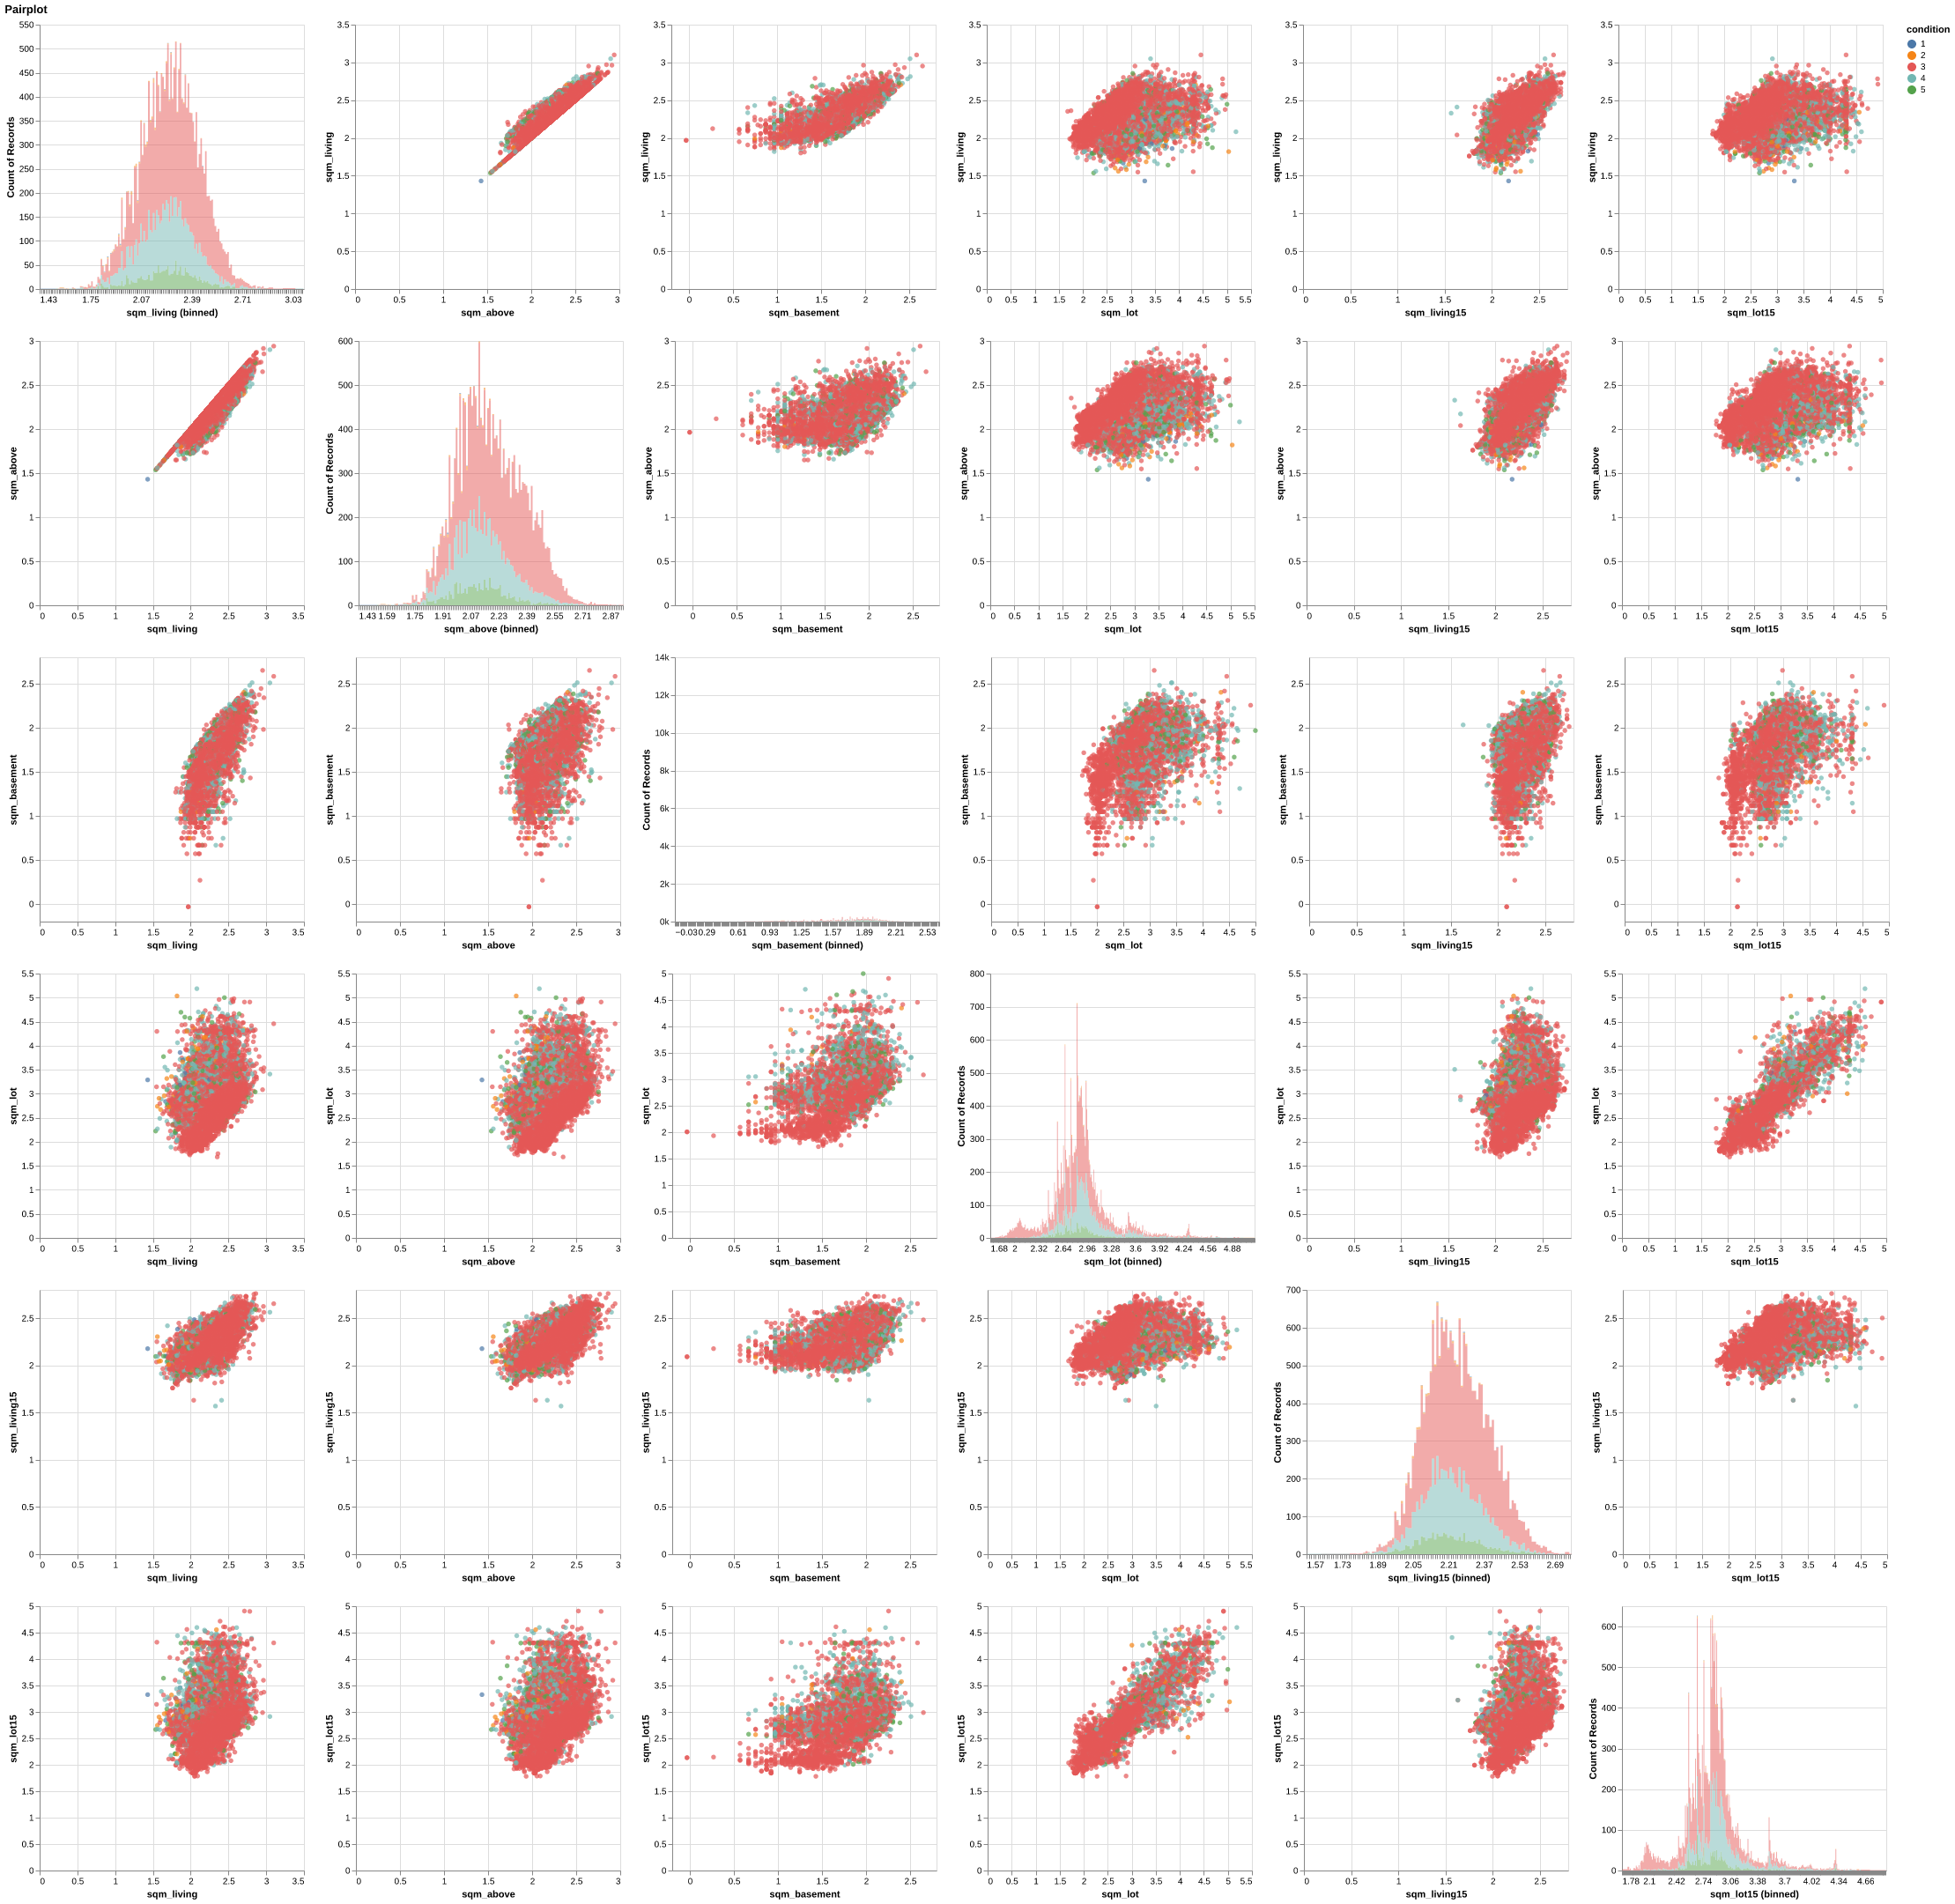

In [40]:
facets = []
features = ['sqm_living', 'sqm_above', 'sqm_basement', 'sqm_lot', 'sqm_living15', 'sqm_lot15']
color = 'condition'

for feature1 in features:
    for feature2 in features:
        if feature1 == feature2:
            chart = alt.Chart(kc_log).mark_area(
                tooltip=True, line=False, opacity=0.5, interpolate='step-after'
                ).encode(
                x=alt.X(f"{feature1}:Q").bin(step=0.01, nice=False).axis(format='~s').stack(None), 
                y=alt.Y("count()").axis(format='~s'),
                color=alt.Color(f"{color}:N")
            )
        else:
            chart = alt.Chart(kc_log).mark_circle(tooltip=True).encode(
                x=alt.X(f"{feature2}:Q").axis(format='~s'),  
                y=alt.Y(f"{feature1}:Q").axis(format='~s'),  
                color=alt.Color(f"{color}:N")
            )
        facets.append(chart)

figure = alt.vconcat(*[alt.hconcat(*facets[i:i+len(features)]) for i in range(0, len(facets), len(features))])
figure = figure.properties(title="Pairplot")
figure.configure_legend(symbolOpacity=1)

In [41]:
for i in range(12):
        print(variance_inflation_factor(
        sm.add_constant(kc_log[['price', 'floors', 'bedrooms', 'bathrooms',
        'yr_built', 'yr_renovated',
        'waterfront', 'view', 'condition', 'grade', 
        'sqm_living', 'sqm_lot']].fillna(0)), i), end='\n')

13267.875679863582
2.8638387758841928
1.8018548747978922
1.7776106666237264
3.249933933309924
2.2355922123816874
1.1423020585915242
1.2126495397026773
1.3523015348380785
1.2247262066015625
3.47610663916212
4.873243450578039


In [43]:
kcz=kc_log.copy()

In [44]:
kcz.apply(lambda x: x.isna().sum())

id                  0
date                0
price               0
floors              0
bedrooms            0
bathrooms           0
yr_built            0
yr_renovated    20699
waterfront          0
view                0
condition           0
grade               0
sqm_living          0
sqm_lot             0
sqm_above           0
sqm_basement    13126
sqm_living15        0
sqm_lot15           0
lat                 0
long                0
dtype: int64

In [ ]:
for col in kcz.loc[:, ['price', 'floors', 'bedrooms', 'bathrooms', 'yr_built',
    'yr_renovated', 'waterfront', 'view', 'condition', 'grade',
    'sqm_living', 'sqm_lot']].columns:
    kcz.loc[:,col] = st.zscore(kcz.loc[:,col])

In [46]:
m_stadardised = smf.ols('price ~ floors + bedrooms + bathrooms + yr_built + waterfront + view + condition + grade + sqm_living + sqm_lot', data=kc)

In [47]:
m_stadardised.fit(cov_type='HC1').summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.652
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     930.9
Date:                Fri, 26 Sep 2025   Prob (F-statistic):               0.00
Time:                        05:17:48   Log-Likelihood:            -2.9619e+05
No. Observations:               21613   AIC:                         5.924e+05
Df Residuals:                   21602   BIC:                         5.925e+05
Df Model:                          10                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   6.298e+06   1.78e+05     35.406      0.000    5.95e+06    6.65e+06
floors       2.42e+04   3944.534      6.134      0.000    1.65e+04    3.19e+04
bedrooms   -3.892e+04   4790.042     -8.126      0.000   -4.83e+04   -2.95e+04
bathrooms   4.694e+04   5091.582      9.219      0.000     3.7e+04    5.69e+04
yr_built   -3622.9581     89.578    -40.445      0.000   -3798.528   -3447.388
waterfront  5.762e+05   6.26e+04      9.210      0.000    4.54e+05    6.99e+05
view        4.544e+04   3967.045     11.456      0.000    3.77e+04    5.32e+04
condition   1.797e+04   2470.983      7.272      0.000    1.31e+04    2.28e+04
grade       1.243e+05   3504.976     35.466      0.000    1.17e+05    1.31e+05
sqm_living  1834.6456     99.549     18.430      0.000    1639.534    2029.758
sqm_lot       -2.7602      0.636     -4.338      0.000      -4.007      -1.513
==============================================================================
Omnibus:                    16045.136   Durbin-Watson:                   1.979
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1108291.752
Skew:                           2.963   Prob(JB):                         0.00
Kurtosis:                      37.577   Cond. No.                     3.67e+05
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 3.67e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [48]:
m_stadardised.fit().bse/100

Intercept     1296.678230
floors          34.244306
bedrooms        20.279667
bathrooms       34.104375
yr_built         0.667692
waterfront     186.258134
view            22.276080
condition       24.621760
grade           21.390677
sqm_living       0.352534
sqm_lot          0.003919
dtype: float64

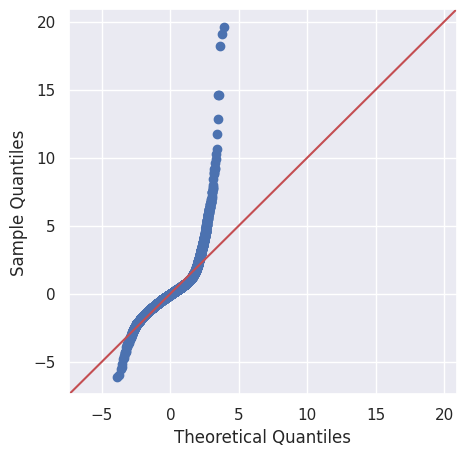

In [49]:
sns.set(rc={"figure.figsize":(5,5)})
sm.qqplot(data = m_stadardised.fit().resid,
          line ='45', fit=True)
plt.show()

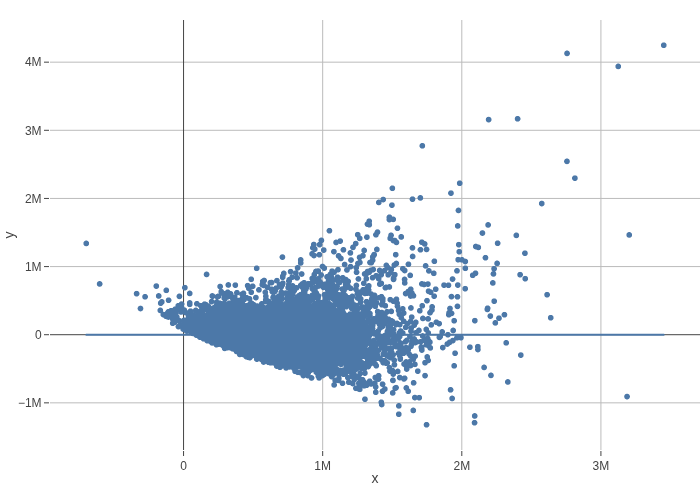

In [50]:
px.scatter(data_frame=kcz, x=m_stadardised.fit().fittedvalues, y=m_stadardised.fit().resid, trendline='ols').show(renderer='png')

In [ ]:
m_stadardised.fit().get_influence().summary_frame()

,dfb_Intercept,dfb_floors,dfb_bedrooms,dfb_bathrooms,dfb_yr_built,dfb_yr_renovated,dfb_waterfront,dfb_view,dfb_condition,dfb_grade,dfb_sqm_living,dfb_sqm_lot,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
1,0.001040,-0.016821,0.010365,0.001302,-0.010769,0.004438,0.001284,0.005038,0.005151,0.014990,-0.012608,0.005117,0.000069,-0.346222,0.006832,-0.028716,-0.346053,-0.028702
35,-0.002319,0.003089,0.010377,-0.006808,0.007931,-0.002517,-0.002126,0.009125,0.004439,-0.004697,0.000477,0.004367,0.000046,-0.434818,0.002932,-0.023581,-0.434622,-0.023570
95,-0.002404,0.006820,-0.000157,0.000674,-0.001277,0.002699,0.000220,0.002864,0.003173,0.008178,-0.011297,0.003819,0.000025,-0.190555,0.008109,-0.017229,-0.190453,-0.017220
103,-0.013449,0.016253,-0.014772,-0.004593,0.006074,0.011143,0.000751,-0.009057,-0.000191,-0.007952,0.014730,-0.004181,0.000083,0.410275,0.005885,0.031567,0.410086,0.031552
115,-0.065202,-0.033777,0.198688,-0.059192,0.163966,-0.038208,-0.003736,0.095059,0.028398,0.141282,-0.238640,0.048680,0.011589,-2.642886,0.019521,-0.372915,-2.651707,-0.374160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19622,0.052168,0.043686,0.022040,-0.006835,0.021003,-0.065957,0.113007,0.023433,-0.048440,-0.014635,-0.027586,-0.011755,0.002902,0.987905,0.034451,0.186606,0.987891,0.186604
20057,-0.031338,0.039578,-0.007896,-0.000194,0.043924,0.007768,-0.000992,-0.003030,-0.001353,-0.016816,-0.008054,-0.005784,0.000342,0.656394,0.009436,0.064066,0.656186,0.064045
20444,0.019552,0.033940,-0.015283,-0.004263,-0.017924,-0.010094,-0.005024,0.013269,0.004260,-0.011472,0.005711,0.007596,0.000310,-0.892007,0.004653,-0.060990,-0.891906,-0.060983
20447,-0.019031,0.019330,0.003295,-0.010178,0.017260,0.009313,0.001910,-0.003007,0.000520,0.011335,-0.014722,-0.000906,0.000119,0.341366,0.012059,0.037714,0.341199,0.037696


In [51]:
px.scatter(data_frame=kcz, x=m_stadardised.fit().fittedvalues, y=m_stadardised.fit().get_influence().summary_frame().cooks_d, trendline='ols').show(renderer='png')